In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from itertools import product
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import sys

In [41]:
df = pd.read_csv("data/ACMETelephoneABT.csv")
y_label = 'churn'
df

,customer,age,occupation,regionType,marriageStatus,children,income,numHandsets,handsetAge,smartPhone,...,avgInCalls,peakOffPeakRatio,peakOffPeakRatioChangePct,avgDroppedCalls,lifeTime,lastMonthCustomerCareCalls,numRetentionCalls,numRetentionOffersAccepted,newFrequentNumbers,churn
0,1000004,26,crafts,town,yes,True,6,1,1812,False,...,0.00,0.362398,-6.330770,0.00,60,0.00,0,0,0,False
1,1000012,36,NaN,NaN,yes,True,9,4,544,True,...,1.67,5.586826,7.499560,0.00,53,0.00,0,0,0,False
2,1000034,74,professional,town,yes,False,7,2,138,True,...,0.33,0.500000,-5.940493,4.33,58,0.00,0,0,3,False
3,1000063,30,NaN,suburban,no,False,6,3,122,True,...,4.67,8.629661,-0.066485,5.33,50,0.33,0,0,0,False
4,1000085,32,NaN,town,yes,False,7,8,10,True,...,23.00,14.042685,-7.208502,14.67,56,0.00,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1099911,52,clerical,unknown,yes,False,4,1,892,True,...,1.00,0.635184,-4.321789,1.33,30,0.00,0,0,0,True
9996,1099923,36,NaN,NaN,yes,False,4,8,337,True,...,1.67,0.794198,0.518042,11.33,33,0.00,0,0,2,True
9997,1099939,28,professional,NaN,no,False,2,4,127,True,...,1.00,0.905522,-1.874074,7.67,33,1.00,0,0,0,True
9998,1099965,0,NaN,NaN,unknown,False,7,5,53,True,...,6.33,1.058214,-18.707600,16.00,31,7.33,0,0,0,True


In [29]:
df.isna().sum()

customer                         0
age                              0
occupation                    7400
regionType                    4776
marriageStatus                   0
children                         0
income                           0
numHandsets                      0
handsetAge                       0
smartPhone                       0
currentHandsetPrice              0
creditRating                     0
homeOwner                        0
creditCard                       0
avgBill                          0
avgMins                          0
avgrecurringCharge               0
avgOverBundleMins                0
avgRoamCalls                     0
callMinutesChangePct             0
billAmountChangePct              0
avgReceivedMins                  0
avgOutCalls                      0
avgInCalls                       0
peakOffPeakRatio                 0
peakOffPeakRatioChangePct        0
avgDroppedCalls                  0
lifeTime                         0
lastMonthCustomerCar

In [42]:
df.drop(columns=['age', 'occupation', 'customer'], inplace=True)
#df['age'] = df['age'].replace(0, np.nan)
#age_imputer = KNNImputer(n_neighbors=2)
#df['age'] = age_imputer.fit_transform(df['age'].values.reshape(-1, 1)).reshape(1, -1)[0]
#df['occupation'].fillna('missing', inplace=True)
df['regionType'].fillna('missing', inplace=True)
df['regionType'] = df['regionType'].replace({'unknown': 'missing', 'r': 'rural', 's': 'suburban', 't': 'town'})

df['children'] = df['children'].map({True: 1, False: 0})
df['smartPhone'] = df['smartPhone'].map({True: 1, False: 0})
df['homeOwner'] = df['homeOwner'].map({True: 1, False: 0})
df['creditCard'] = df['creditCard'].map({'TRUE': 1, 'FALSE': 0, 'no': 0, 't': 1, 'f': 0, 'yes': 1})
df['creditRating'] = df['creditRating'].map({'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1})
df['churn'] = df['churn'].map({True: 1, False: 0})

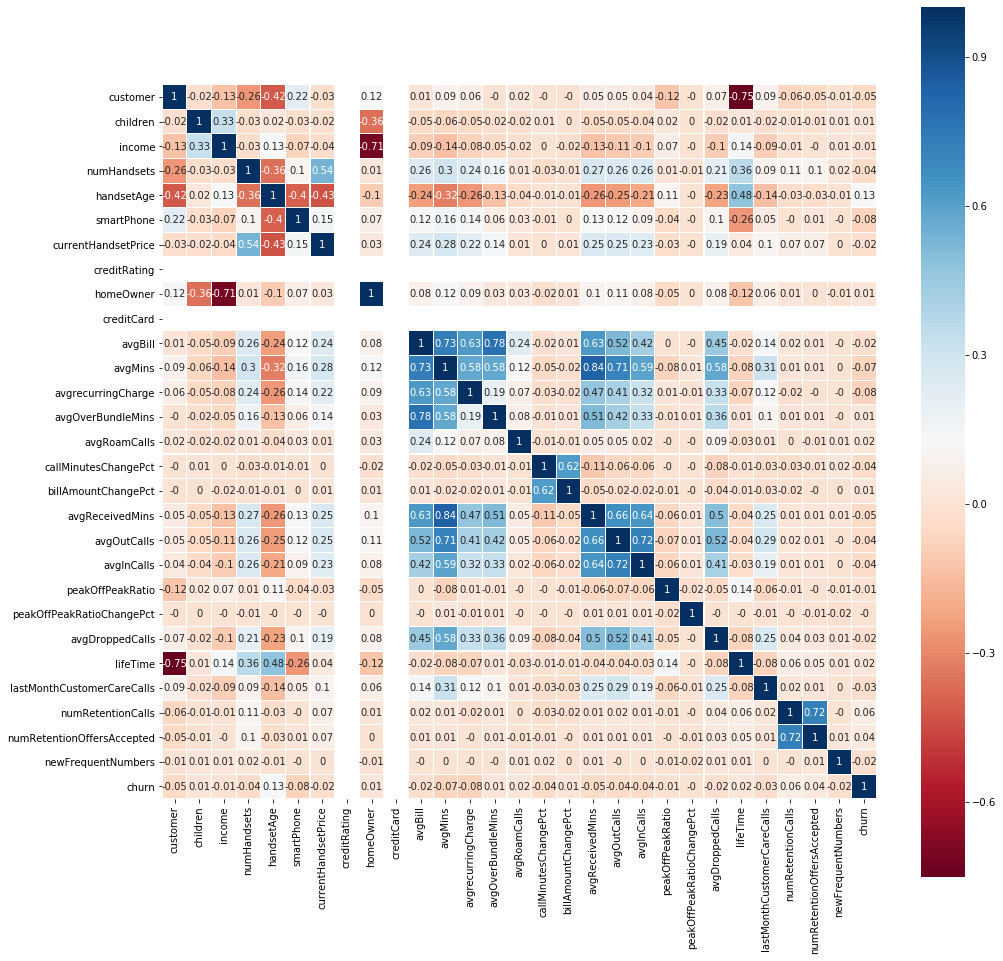

In [26]:
colormap = plt.cm.RdBu
f, axs = plt.subplots(1, 1, figsize=(16, 16))
sns.heatmap(df.corr(method='pearson', min_periods=1).round(decimals=2), linewidths=0.1, vmax=1.0, square=True, 
            cmap=colormap, linecolor='white', annot=True)
#plt.xticks(rotation=30, fontsize=7)
plt.show()

Train test split

In [43]:
ctg_columns = ['regionType', 'marriageStatus']
df_dummy = pd.get_dummies(df, columns=ctg_columns)
df_dummy

,children,income,numHandsets,handsetAge,smartPhone,currentHandsetPrice,creditRating,homeOwner,creditCard,avgBill,...,numRetentionOffersAccepted,newFrequentNumbers,churn,regionType_missing,regionType_rural,regionType_suburban,regionType_town,marriageStatus_no,marriageStatus_unknown,marriageStatus_yes
0,1,6,1,1812,0,0.00,5,1,1,38.00,...,0,0,0,0,0,0,1,0,0,1
1,1,9,4,544,1,79.99,7,0,1,35.30,...,0,0,0,1,0,0,0,0,0,1
2,0,7,2,138,1,29.99,7,0,1,21.15,...,0,3,0,0,0,0,1,0,0,1
3,0,6,3,122,1,9.99,5,0,1,91.18,...,0,0,0,0,0,1,0,1,0,0
4,0,7,8,10,1,129.99,7,0,1,93.02,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,4,1,892,1,0.00,5,1,1,32.32,...,0,0,1,1,0,0,0,0,0,1
9996,0,4,8,337,1,59.99,5,0,0,0.00,...,0,2,1,1,0,0,0,0,0,1
9997,0,2,4,127,1,29.99,6,0,1,57.67,...,0,0,1,1,0,0,0,1,0,0
9998,0,7,5,53,1,59.99,3,0,1,0.00,...,0,0,1,1,0,0,0,0,1,0


In [57]:
df_normed = df_dummy.copy()

column_to_nmlz = list(set(df_normed.columns) - set(['children', 'smartPhone', 'homeOwner', y_label]))
df_normed[column_to_nmlz] = StandardScaler().fit_transform(df_normed[column_to_nmlz])
train_set_normed, test_set_normed = train_test_split(df_normed, test_size=0.1, random_state=42)
train_set, test_set = train_test_split(df_dummy, test_size=0.1, random_state=43)

x_train_normed = train_set_normed.drop(columns=[y_label], axis=1)
x_test_normed = test_set_normed.drop(columns=[y_label], axis=1)
y_train_normed = train_set_normed[y_label]
y_test_normed = test_set_normed[y_label]

x_train = train_set.drop(columns=[y_label], axis=1)
x_test = test_set.drop(columns=[y_label], axis=1)
y_train = train_set[y_label]
y_test = test_set[y_label]

In [92]:
y_train.value_counts()

1    4515
0    4485
Name: churn, dtype: int64

In [65]:
def dict_product(d):
    keys = d.keys()
    for element in product(*d.values()):
        yield dict(zip(keys, element))

def GridSearchWithVal(model_class, param_grid, metrics='accuracy', cv=5, normed=False):
    combinations = list(dict_product(param_grid))
    max_metrics = 0
    best_comb = None
    X_train = x_train if normed is False else x_train_normed
    Y_train = y_train if normed is False else y_train_normed
    X_test = x_test if normed is False else x_test_normed
    Y_test = y_test if normed is False else y_test_normed

    print("{} combinations in total. Metric: {}".format(len(combinations), metrics))
    for idx, comb in enumerate(combinations):
        model = model_class(**comb)
        model.fit(X_train, Y_train)
        y_preds = model.predict(X_test)
        # print("y_preds:{}".format(y_preds))
        # print("y_test:{}".format(y_test.values))
        error = 0;

        #scores = cross_val_score(model, X, Y, cv=cv, scoring=metrics)
        n_correct = sum(y_preds == Y_test)
        acc = float(n_correct) / len(y_preds)
        metrics_num = acc

        if metrics_num > max_metrics:
            max_metrics = metrics_num
            best_comb = comb
        progress_str = "{} / {}, best comb: {}, best score: {}".format(idx + 1, len(combinations), best_comb, max_metrics)
        sys.stdout.write('\r' + progress_str)

    print("best params:{}".format(best_comb))
    print("max {}: {}".format(metrics, max_metrics))
    return best_comb

Gradient Boosting

In [109]:
gb_param_grid = {"n_estimators" : [10, 30, 50, 70],
                  "loss" : ["deviance", "exponential"],
                  "learning_rate": [0.03, 0.05, 0.08, 0.1],
                  "max_depth": [2, 5, 10, None],
                  "min_samples_leaf": [100, 200, 300, 400],
                  "max_features": [0.1, 0.3, 0.5, None]
                }
gbc_best_param = GridSearchWithVal(GradientBoostingClassifier, gb_param_grid)

2048 combinations in total. Metric: accuracy
2048 / 2048, best comb: {'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': None, 'min_samples_leaf': 300, 'max_features': 0.5}, best score: 0.629best params:{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': None, 'min_samples_leaf': 300, 'max_features': 0.5}
max accuracy: 0.629


Neural Network

In [90]:
def create_keras_model(optimizer='adam', neuron=50, init='lecun_normal', act_alpha=0.1):
    model_sequences = [
        keras.layers.Dense(units=neuron, kernel_initializer=init,
                           activation='relu',
                           input_shape=x_train_normed.shape[1:]
                           ),
        keras.layers.Dropout(rate=0.1, input_shape=x_train_normed.shape[1:]),

        #keras.layers.LeakyReLU(alpha=act_alpha)
    ]

    for i in range(2):
        model_sequences.append(keras.layers.Dense(units=neuron, kernel_initializer=init,
                                                  activation='relu',
                                                  input_shape=x_train_normed.shape[1:]))
        keras.layers.Dropout(rate=0.1, input_shape=x_train_normed.shape[1:]),

        #model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))

    # model_sequences.append(keras.layers.BatchNormalization())
    model_sequences.append(Dense(units=1, name='score_output',
                                 activation='sigmoid'
                                 ))
    # model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))

    nn_model = keras.models.Sequential(model_sequences)
    nn_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return nn_model

Keras model constructed
Train on 9000 samples, validate on 1000 samples
Epoch 1/30
9000/9000 [==============================] - 5s 522us/step - loss: 0.6905 - acc: 0.5327 - val_loss: 0.6873 - val_acc: 0.5310
Epoch 2/30
9000/9000 [==============================] - 1s 105us/step - loss: 0.6827 - acc: 0.5581 - val_loss: 0.6825 - val_acc: 0.5550
Epoch 3/30
9000/9000 [==============================] - 1s 104us/step - loss: 0.6774 - acc: 0.5743 - val_loss: 0.6864 - val_acc: 0.5550
Epoch 4/30
9000/9000 [==============================] - 1s 105us/step - loss: 0.6724 - acc: 0.5844 - val_loss: 0.6886 - val_acc: 0.5620
Epoch 5/30
9000/9000 [==============================] - 1s 106us/step - loss: 0.6698 - acc: 0.5922 - val_loss: 0.6827 - val_acc: 0.5680
Epoch 6/30
9000/9000 [==============================] - 1s 104us/step - loss: 0.6644 - acc: 0.5988 - val_loss: 0.6803 - val_acc: 0.5620
Epoch 7/30
9000/9000 [==============================] - 1s 103us/step - loss: 0.6613 - acc: 0.5951 - val_loss: 0

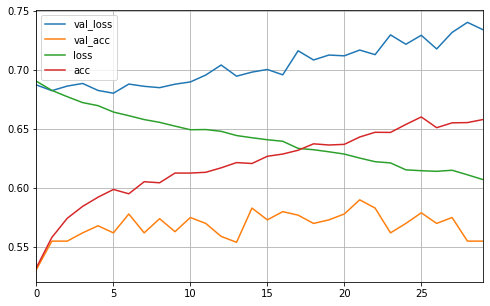

In [91]:
optimizer = keras.optimizers.Adadelta(lr=1e-3)
sgd = SGD(lr=0.01, decay=0.000001, momentum=0.9)
nn_model = create_keras_model(optimizer=sgd, neuron=50, init='lecun_uniform', act_alpha=0.05)
print("Keras model constructed")
#early_stopping_cb = EarlyStopping(patience=20)
history = nn_model.fit(x_train_normed, y_train_normed, validation_data=(x_test_normed, y_test_normed), epochs=30, callbacks=[], verbose=1)
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()